In [1]:
print("ALL OK")

ALL OK


In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

GEMINI_API_KEY=os.getenv("GEMINI_API_KEY")
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
GROQ_API_KEY=os.getenv("GROQ_API_KEY")
LANGCHAIN_API_KEY=os.getenv("LANGCHAIN_API_KEY")
assert GEMINI_API_KEY, "GEMINI_API_KEY is not set"
os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY
os.environ["TAVILY_API_KEY"] = TAVILY_API_KEY

os.environ["GROQ_API_KEY"]= GROQ_API_KEY
os.environ["LANGCHAIN_API_KEY"] = LANGCHAIN_API_KEY
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"

In [3]:
from groq import Groq
from langchain_groq import ChatGroq
import os

client = Groq(api_key=os.environ["GROQ_API_KEY"])

preferred_models = [
    "llama-3.3-70b-versatile",
    "llama-3.1-8b-instant",
    "mixtral-8x7b-32768",
]

available = [m.id for m in client.models.list().data]
assert available, "No models available for this Groq API key"

model_name = next((m for m in preferred_models if m in available), available[0])
print("Using model:", model_name)

chat_llm = ChatGroq(
    api_key=os.environ["GROQ_API_KEY"],
    model_name=model_name
)


Using model: llama-3.3-70b-versatile


In [4]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [5]:
api_wrapper = WikipediaAPIWrapper(top_k_results=5, doc_content_chars_max= 500)

In [6]:
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper)

In [7]:
wiki_tool.run({"query":"Generative AI"})

'Page: Generative artificial intelligence\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI to'

In [8]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

In [9]:
TAVILY_API_KEY

'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'

In [10]:
tool = TavilySearchResults(tavily_api_key = TAVILY_API_KEY)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15828\721283573.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(tavily_api_key = TAVILY_API_KEY)


In [11]:
tool.invoke({"query": "how is the CSE job market for graduates in 2026 "})

[{'title': '2026 Is Demand for Computer Science Degree Graduates Growing ...',
  'url': 'https://research.com/advice/is-demand-for-computer-science-degree-graduates-growing-or-declining',
  'content': '# 2026 Is Demand for Computer Science Degree Graduates Growing or Declining?\n\nby\n Imed Bouchrika, PhD\n\nCo-Founder and Chief Data Scientist\n\nShare\n\nGraduates with a computer science degree often face uncertainty about whether their skills align with evolving job market demands. Rapid technological advances and shifting industry needs create challenges in securing relevant positions. Employment projections from the U. S. Bureau of Labor Statistics show a 21% growth rate for computer and information technology occupations from 2021 to 2031, much faster than the average for all occupations. [...] Growth rates serve as a vital signal for students evaluating computer science career paths, indicating where job security and advancement opportunities are strongest. According to recent la

In [12]:
# DUCKDUCKGO
from langchain_community.tools import DuckDuckGoSearchResults
search = DuckDuckGoSearchResults()

In [13]:
search.invoke("what is the latest update on iphone 17 release?")

Impersonate 'chrome_124' does not exist, using 'random'


"snippet: Oct 9, 2025 · Apple has unveiled four new iPhones: the iPhone 17 , iPhone Air, iPhone 17 Pro and iPhone 17 Pro Max. Here’s the lowdown on the specs, price, new features, design, dimensions and more., title: New iPhone Air, 17, 17 Pro & Max release date, specs ..., link: https://www.macworld.com/article/2393967/iphone-17-release-date-specs-features-rumors.html, snippet: Sep 9, 2025 · iPhone 17 introduces N1, a new Apple-designed wireless networking chip that enables Wi-Fi 7, Bluetooth 6, and Thread. In addition to the latest generation of wireless technologies, N1 improves the overall performance and reliability of features like Personal Hotspot and AirDrop., title: Apple debuts iPhone 17 - Apple, link: https://www.apple.com/newsroom/2025/09/apple-debuts-iphone-17/, snippet: We covered the Apple event below, and you can read our minute-by-minute account below of all of the company's announcements, along with updates as we get some hands-on time with the new phones..., title: i

In [14]:
from langchain_community.tools import YouTubeSearchTool
tool = YouTubeSearchTool()

In [15]:
tool.name

'youtube_search'

In [16]:
tool.description

'search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional'

In [17]:
tool.run("carrer247")

"['https://www.youtube.com/watch?v=EASWWivv_Xw&pp=ygUJY2FycmVyMjQ3', 'https://www.youtube.com/watch?v=Aj-TGMJ1658&pp=ygUJY2FycmVyMjQ3']"

In [18]:
multiply(10,20)

NameError: name 'multiply' is not defined

In [ ]:
from langchain.tools import tool 

In [ ]:
@tool
def multiply(a:int,b:int) -> int:
    '''Multiples of two numbers'''
    return a*b

In [ ]:
multiply.invoke({"a" : 10, "b": 30})

300

In [ ]:
#now creating the list of the tools

[multiply]

In [27]:
from typing_extensions import TypedDict, Annotated
import operator

In [26]:
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage

In [28]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [29]:
{
    "messages" : [HumanMessage(content= "Hi, this is jayant, say hello")]
    
}

{'messages': [HumanMessage(content='Hi, this is jayant, say hello', additional_kwargs={}, response_metadata={})]}

In [30]:
["HI"]

['HI']

In [31]:
def llm_call(state: GraphState)-> dict:
    """Call the LLM using conversation messages and append AI response"""
    response = chat_llm.invoke(state["messages"])
    return{
        "messages" : [response]
    }

In [32]:
def token_counter(state: GraphState) -> dict:
    last_msg = state["messages"][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number generated answer (word count) is {token_number}"
    return {
        "messages": [AIMessage(content=summary)]
    }


In [22]:
from langgraph.graph import StateGraph

In [33]:
builder = StateGraph(GraphState)

In [34]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [35]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

In [36]:
app = builder.compile()

In [37]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

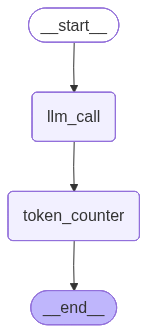

In [ ]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [38]:
result = app.invoke({
    "messages": [HumanMessage(content="Hi, this is Sunny. Say hello in detail.")]
})
print(result)

{'messages': [HumanMessage(content='Hi, this is Sunny. Say hello in detail.', additional_kwargs={}, response_metadata={}), AIMessage(content="Hello Sunny, it's an absolute delight to connect with you. I hope this message finds you beaming with joy and having a fantastic day, filled with endless possibilities and exciting opportunities. As we begin our conversation, I want to take a moment to appreciate the beautiful name you have - Sunny, which instantly evokes feelings of warmth, happiness, and brightness. It's a pleasure to make your acquaintance, and I'm looking forward to chatting with you, learning more about your interests, and sharing knowledge on a wide range of topics. So, please feel free to ask me anything, share your thoughts, or simply say hello - I'm all ears and here to help. How's your day going so far, Sunny?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 146, 'prompt_tokens': 46, 'total_tokens': 192, 'completion_time': 0.551605634, 'co